# 🌍 World Countries — Geographic Visualization

Visualizes world countries using their latitude & longitude coordinates with three different methods:

| # | Method | Description |
|---|--------|-------------|
| 1 | **Folium** | Interactive map with colored markers for each country |
| 2 | **Plotly** | Choropleth map — countries colored by latitude relative to the equator |
| 3 | **Matplotlib** | Scatter plot showing global distribution with latitude zones |

**Data Source:** MongoDB collection `world_country.countries`

### Cell 1 — Folium Interactive Map
Loads country coordinates from MongoDB, filters small islands, and plots each country as a colored marker on an interactive map.

In [5]:
# Step 1: Import data manipulation and Folium mapping libraries
import pandas as pd
import folium
from pymongo import MongoClient

# Step 2: Define ISO codes of small islands/territories to exclude
SMALL_ISLANDS = {
    'AI','AN','AS','AW','BB','BL','BM','BV','CC','CK','CV','CX',
    'DM','FK','FM','FO','GD','GI','GP','GS','GU','HM','IO','KI',
    'KM','KN','KY','LC','LI','MC','MH','MP','MQ','MS','MU','MV',
    'NC','NF','NR','NU','PF','PM','PR','PW','RE','SB','SC','SH',
    'SJ','SM','ST','TC','TF','TK','TO','TT','TV','UM','VA','VC',
    'VG','VI','VU','WF','WS','YT','AP','EU'
}

# Step 3: Establish connection to local MongoDB instance
client = MongoClient('mongodb://localhost:27017/')

# Step 4: Access database and collection storing geospatial data
db = client['world_country']
collection = db['countries']

# Step 5: Retrieve collection records into DataFrame
df = pd.DataFrame(list(collection.find()))

# Step 6: Cast spatial coordinate columns to float data types
df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')

# Step 7: Filter out small islands and non-country entries
df = df[~df['ISO 3166 Country Code'].isin(SMALL_ISLANDS)]

# Step 8: Initialize interactive Folium map centered globally
m = folium.Map(location=[0, 0], zoom_start=2)

# Step 9: Add country markers with tooltips to the map
for index, row in df.iterrows():
    if pd.notnull(row['Latitude']) and pd.notnull(row['Longitude']):
        folium.Marker(
            location=[row['Latitude'], row['Longitude']],
            tooltip=(
            f"<b>{row['Country']}</b><br>"
            f"Lat: {row['Latitude']:.1f}° | Lon: {row['Longitude']:.1f}°"
        ),
            icon=folium.Icon(color='blue', icon='cloud')
        ).add_to(m)

# Step 10: Render Folium map
m

### Cell 2 — Plotly Choropleth Map
Reads CSV coordinates, classifies each country by its position relative to the **Equator** (Above / On / Below), and draws a choropleth map colored by latitude.

In [6]:
# Imports
import pandas as pd
import plotly.graph_objects as go

# Load CSV (SMALL_ISLANDS defined in Cell 1)
df = pd.read_csv('average-latitude-longitude-countries.csv')

# Parse coordinates
df['Latitude']  = pd.to_numeric(df['Latitude'],  errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')
df = df.dropna(subset=['Latitude', 'Longitude'])

# Filter small islands
df = df[~df['ISO 3166 Country Code'].isin(SMALL_ISLANDS)].copy()

# Classify by equator position
THRESHOLD = 2.0
def equator_position(lat):
    if abs(lat) <= THRESHOLD:
        return 'On the Equator'
    elif lat > 0:
        return 'Above the Equator'
    else:
        return 'Below the Equator'

df['Position'] = df['Latitude'].apply(equator_position)

# Build choropleth map
fig = go.Figure(go.Choropleth(
    locations=df['Country'],
    locationmode='country names',
    z=df['Latitude'],
    customdata=list(zip(
        df['Country'],
        df['Latitude'].round(1),
        df['Longitude'].round(1),
        df['Position']
    )),
    hovertemplate=(
        '<b>%{customdata[0]}</b><br>'
        '──────────────────<br>'
        '📍 Lat: %{customdata[1]}°  |  Lon: %{customdata[2]}°<br>'
        '🌐 %{customdata[3]}'
        '<extra></extra>'
    ),
    colorscale=[
        [0.0,   '#1a237e'],
        [0.2,   '#1565c0'],
        [0.38,  '#26c6da'],
        [0.5,   '#a5d6a7'],
        [0.62,  '#ffca28'],
        [0.8,   '#ef5350'],
        [1.0,   '#b71c1c'],
    ],
    zmin=-90, zmax=90,
    showscale=False,
    marker_line_color='rgba(255,255,255,0.6)',
    marker_line_width=0.6,
))

# Layout and styling
fig.update_layout(
    title=dict(
        text='🌍 World Map: Countries by Position Relative to the Equator',
        font=dict(size=19, color='#1a1a2e', family='Arial'),
        x=0.5, xanchor='center', y=0.95
    ),
    height=460,
    width=860,
    paper_bgcolor='#eef2f7',
    margin=dict(l=10, r=10, t=65, b=10),
    showlegend=False,
    geo=dict(
        projection_type='natural earth',
        showcoastlines=True,
        coastlinecolor='#546e7a',
        coastlinewidth=0.6,
        showland=True,
        landcolor='#cfd8dc',
        showocean=True,
        oceancolor='#b3d9f2',
        showcountries=True,
        countrycolor='rgba(255,255,255,0.7)',
        countrywidth=0.5,
        showlakes=True,
        lakecolor='#b3d9f2',
        bgcolor='#eef2f7',
        lataxis=dict(showgrid=True, gridcolor='rgba(80,80,80,0.15)', gridwidth=0.5, dtick=30),
        lonaxis=dict(showgrid=True, gridcolor='rgba(80,80,80,0.15)', gridwidth=0.5, dtick=30),
    )
)

# Step 8: Add dashed equator line
fig.add_scattergeo(
    lat=[0]*361,
    lon=list(range(-180, 181)),
    mode='lines',
    line=dict(color='#e53935', width=3, dash='dash'),
    showlegend=False,
    hoverinfo='skip'
)

# Render
fig.show()


C:\Users\Alimm\AppData\Local\Temp\ipykernel_46980\4092222371.py:51: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = go.Figure(go.Choropleth(


### Cell 3 — Matplotlib Scatter Plot
Loads coordinates from MongoDB and plots longitude vs latitude with latitude zone bands (Arctic, Temperate, Tropics) and plasma colorscale.

C:\Users\Alimm\AppData\Local\Temp\ipykernel_46980\3331853722.py:78: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Alimm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


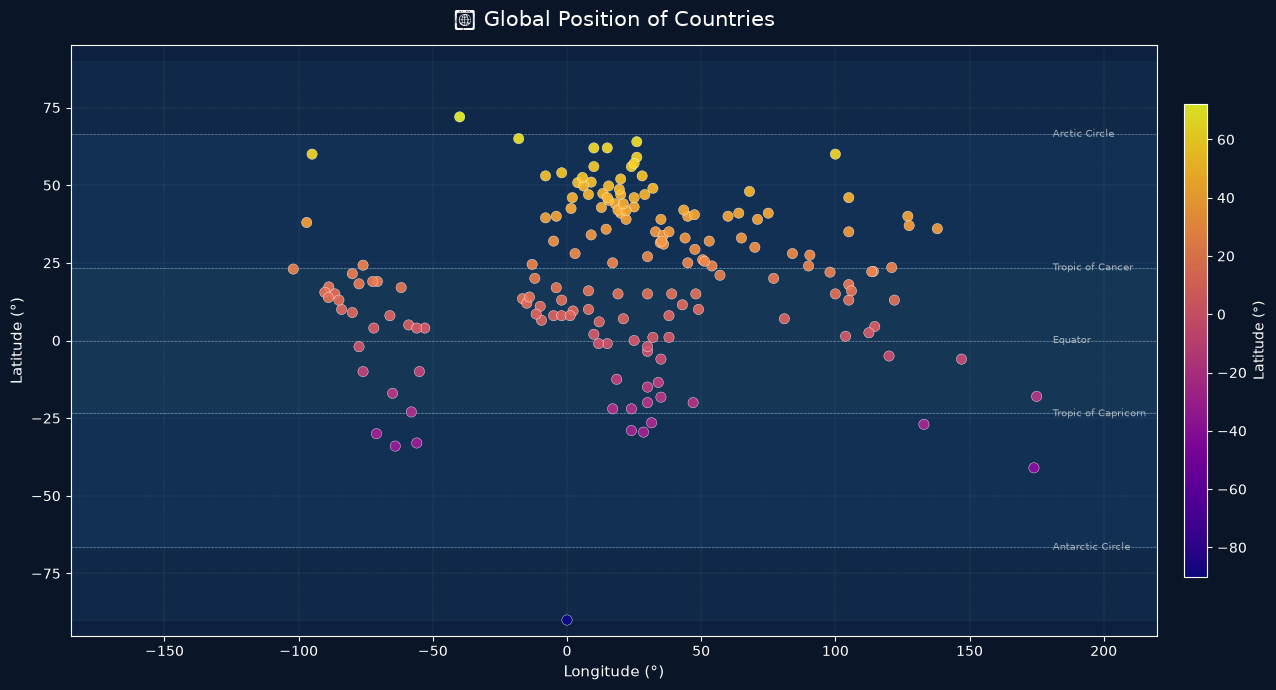

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from pymongo import MongoClient

# Load from MongoDB
client = MongoClient('mongodb://localhost:27017')
df = pd.DataFrame(list(client['world_country']['countries'].find()))

# Parse coordinates and filter
df['Latitude']  = pd.to_numeric(df['Latitude'],  errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')
df = df[~df['ISO 3166 Country Code'].isin(SMALL_ISLANDS)]
df = df.dropna(subset=['Latitude', 'Longitude'])

# Dark ocean theme
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#0a1628')
ax.set_facecolor('#0d2040')

# Latitude zone bands
zones = [
    (-90,   -66.5, '#1a3a5c', 'Antarctic'),
    (-66.5, -23.5, '#1e4d7a', 'Southern Temperate'),
    (-23.5,  23.5, '#24607a', 'Tropics'),
    ( 23.5,  66.5, '#1e4d7a', 'Northern Temperate'),
    ( 66.5,  90,   '#1a3a5c', 'Arctic'),
]
for ymin, ymax, color, label in zones:
    ax.axhspan(ymin, ymax, alpha=0.35, color=color, label=label)

# Scatter colored by latitude
scatter = ax.scatter(
    df['Longitude'], df['Latitude'],
    c=df['Latitude'], cmap='plasma',
    s=55, alpha=0.9, edgecolors='white', linewidths=0.3, zorder=3
)

# Colorbar
cbar = fig.colorbar(scatter, ax=ax, pad=0.02, shrink=0.8)
cbar.set_label('Latitude (°)', color='white', fontsize=10)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

# Reference latitude lines
refs = [(-66.5, 'Antarctic Circle'), (-23.5, 'Tropic of Capricorn'),
        (0, 'Equator'), (23.5, 'Tropic of Cancer'), (66.5, 'Arctic Circle')]
for lat, lbl in refs:
    ax.axhline(lat, color='white', linewidth=0.5, linestyle='--', alpha=0.4)
    ax.text(181, lat, lbl, color='white', fontsize=7, va='center', alpha=0.6)

ax.grid(color='white', linestyle='--', linewidth=0.3, alpha=0.2)
ax.set_title('🌍 Global Position of Countries', color='white', fontsize=15, pad=14)
ax.set_xlabel('Longitude (°)', color='white', fontsize=11)
ax.set_ylabel('Latitude (°)',  color='white', fontsize=11)
ax.set_xlim(-185, 220)
ax.set_ylim(-95, 95)
ax.tick_params(colors='white')

plt.tight_layout()
plt.show()
